# Modelo de Ising con campo transverso y como simularlo

In [18]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt


# -------------------------
# Parámetros del sistema
# -------------------------

n_qubits = 4
J = 1.0
h = 1.0

dev = qml.device(
    "default.qubit",
    wires=n_qubits
)

In [19]:
def trotter_step(
    dt: float,
    J: float,
    h: float,
    n_qubits: int
) -> None:
    """
    Aplica un paso de Trotter de primer orden
    para el modelo de Ising de campo transversal.
    """

    # Evolución por las interacciones ZZ
    for i in range(n_qubits - 1):
        qml.IsingZZ(
            -2.0 * J * dt,
            wires=[i, i + 1]
        )

    # Evolución por el campo transversal X
    for i in range(n_qubits):
        qml.RX(
            -2.0 * h * dt,
            wires=i
        )

In [20]:
@qml.qnode(dev)
def tfim_trotter_circuit(
    total_time: float,
    steps: int,
    J: float,
    h: float
):
    """
    Evolución trotterizada del TFIM
    desde el estado inicial |0000>.
    """

    if steps <= 0:
        raise ValueError("steps debe ser mayor que cero.")

    dt = total_time / steps

    # Estado inicial |0000>
    # No se necesita aplicar ninguna compuerta.

    for _ in range(steps):
        trotter_step(
            dt=dt,
            J=J,
            h=h,
            n_qubits=n_qubits
        )

    return [
        qml.expval(qml.PauliZ(i))
        for i in range(n_qubits)
    ]

In [21]:
total_time = 1.0
steps = 10

z_values = tfim_trotter_circuit(
    total_time=total_time,
    steps=steps,
    J=J,
    h=h
)

z_values = np.array(z_values)

magnetization_z = np.mean(z_values)

print("<Zi> =", z_values)
print("Mz =", magnetization_z)

<Zi> = [-0.03517818  0.30106817  0.30106817 -0.03517818]
Mz = 0.13294499578559577


In [22]:
@qml.qnode(dev)
def tfim_observables(
    total_time: float,
    steps: int,
    J: float,
    h: float
):
    dt = total_time / steps

    for _ in range(steps):
        trotter_step(
            dt=dt,
            J=J,
            h=h,
            n_qubits=n_qubits
        )

    magnetizations = [
        qml.expval(qml.PauliZ(i))
        for i in range(n_qubits)
    ]

    correlations = [
        qml.expval(
            qml.PauliZ(i) @ qml.PauliZ(i + 1)
        )
        for i in range(n_qubits - 1)
    ]

    return magnetizations + correlations

In [23]:
results = np.array(
    tfim_observables(
        total_time=1.0,
        steps=10,
        J=1.0,
        h=1.0
    )
)

z_values = results[:n_qubits]
zz_values = results[n_qubits:]

print("<Zi> =", z_values)
print("<Zi Zi+1> =", zz_values)

print("Mz =", np.mean(z_values))
print("Czz =", np.mean(zz_values))

<Zi> = [-0.03517818  0.30106817  0.30106817 -0.03517818]
<Zi Zi+1> = [0.42941133 0.43800504 0.42941133]
Mz = 0.13294499578559577
Czz = 0.4322758979991496


In [24]:
times = np.linspace(
    0.0,
    5.0,
    101
)

magnetization_values = []
correlation_values = []

steps_per_unit_time = 20

for t in times:

    if t == 0:
        mz = 1.0
        czz = 1.0

    else:
        steps = max(
            1,
            int(np.ceil(steps_per_unit_time * t))
        )

        results = np.array(
            tfim_observables(
                total_time=t,
                steps=steps,
                J=J,
                h=h
            )
        )

        z_values = results[:n_qubits]
        zz_values = results[n_qubits:]

        mz = np.mean(z_values)
        czz = np.mean(zz_values)

    magnetization_values.append(mz)
    correlation_values.append(czz)

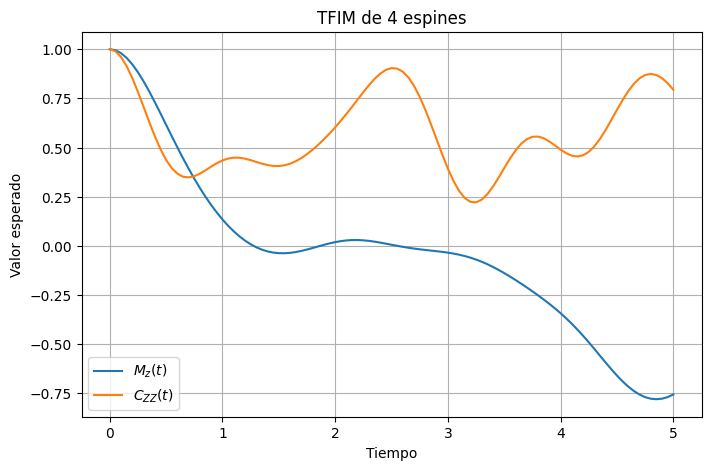

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    times,
    magnetization_values,
    label=r"$M_z(t)$"
)

plt.plot(
    times,
    correlation_values,
    label=r"$C_{ZZ}(t)$"
)

plt.xlabel("Tiempo")
plt.ylabel("Valor esperado")
plt.title("TFIM de 4 espines")
plt.legend()
plt.grid()
plt.show()

In [26]:
drawer = qml.draw(
    tfim_trotter_circuit
)

print(
    drawer(
        total_time=1.0,
        steps=2,
        J=1.0,
        h=1.0
    )
)

0: ─╭IsingZZ(-1.00)──RX(-1.00)──────────────────────╭IsingZZ(-1.00)──RX(-1.00)───── ···
1: ─╰IsingZZ(-1.00)─╭IsingZZ(-1.00)──RX(-1.00)──────╰IsingZZ(-1.00)─╭IsingZZ(-1.00) ···
2: ─────────────────╰IsingZZ(-1.00)─╭IsingZZ(-1.00)──RX(-1.00)──────╰IsingZZ(-1.00) ···
3: ─────────────────────────────────╰IsingZZ(-1.00)──RX(-1.00)───────────────────── ···

0: ··· ────────────────────────────┤  <Z>
1: ··· ──RX(-1.00)─────────────────┤  <Z>
2: ··· ─╭IsingZZ(-1.00)──RX(-1.00)─┤  <Z>
3: ··· ─╰IsingZZ(-1.00)──RX(-1.00)─┤  <Z>
